In [1]:
# Dependencies
library(here)
library(ggplot2)
library(dplyr)
library(leaps)
library(tidyr)
library(corrplot)
library(car)
library(MASS)
library(MuMIn)
library(caret)
library(lmtest)

here() starts at /Users/amberteetsel/MSDS/STAT_5010/opioid-crisis


Attaching package: ‘dplyr’


The following objects are masked from ‘package:stats’:

    filter, lag


The following objects are masked from ‘package:base’:

    intersect, setdiff, setequal, union


corrplot 0.95 loaded

Loading required package: carData


Attaching package: ‘car’


The following object is masked from ‘package:dplyr’:

    recode



Attaching package: ‘MASS’


The following object is masked from ‘package:dplyr’:

    select


Loading required package: lattice

Loading required package: zoo


Attaching package: ‘zoo’


The following objects are masked from ‘package:base’:

    as.Date, as.Date.numeric




In [2]:
# Load data
df <- read.csv(here("data", "death_rate_nb.csv"))
head(df)

,state,year,deaths,death_rate,hydro_gms,oxy_gms,fent_gms,pop,unempl_rate,poverty_rate,snap_rate,medicaid_rate,gsp_per_cap,min_wage,log_pop,log_hydro,log_oxy,log_fent,log_death_rate
,<chr>,<int>,<int>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
1,AL,2000,197,-1.308400,-0.1037009,-0.07198984,-0.08602873,-0.2396840,-0.73962867,0.1942059,-0.38573312,-0.62386327,-1.6618041,-1.026754,15.30890,-0.3974345,-0.9192862,-0.9234053,-1.787006
2,AL,2001,216,-1.241686,-0.1035686,-0.07195101,-0.08602885,-0.2373706,-0.49287538,0.9488591,-0.31689900,-0.18631157,-1.6108019,-1.026754,15.31237,-0.3637661,-0.8364945,-0.9250998,-1.627562
3,AL,2002,211,-1.262992,-0.1032225,-0.07193209,-0.08601729,-0.2355071,-0.13312766,0.5559496,-0.16282797,0.06299210,-1.5138153,-1.026754,15.31515,-0.2837199,-0.8000439,-0.7838532,-1.677258
4,AL,2003,197,-1.317015,-0.1028859,-0.07191409,-0.08600594,-0.2320056,-0.07274793,0.6885560,-0.03373072,0.09102397,-1.4083021,-1.026754,15.32036,-0.2149542,-0.7673390,-0.6757568,-1.808450
5,AL,2004,283,-1.001213,-0.1025557,-0.07189656,-0.08599476,-0.2279301,-0.22717372,1.3322157,0.07729171,0.21132943,-1.1632969,-1.026754,15.32639,-0.1543956,-0.7371711,-0.5882937,-1.132110
6,AL,2005,283,-1.004699,-0.1022392,-0.07188020,-0.08598392,-0.2220834,-0.83051811,1.2020409,0.35266288,0.28930908,-0.9977787,-1.026754,15.33498,-0.1015865,-0.7103351,-0.5160579,-1.138560


In [3]:
mod_nb <- glm.nb(deaths ~ log_oxy + log_fent + log_hydro +
                   snap_rate + unempl_rate + poverty_rate +
                   medicaid_rate + gsp_per_cap + min_wage +
                   offset(log_pop),
                 data = df)
summary(mod_nb)

exp(coef(mod_nb))


Call:
glm.nb(formula = deaths ~ log_oxy + log_fent + log_hydro + snap_rate + 
    unempl_rate + poverty_rate + medicaid_rate + gsp_per_cap + 
    min_wage + offset(log_pop), data = df, init.theta = 7.799484211, 
    link = log)

Coefficients:
               Estimate Std. Error  z value Pr(>|z|)    
(Intercept)   -9.044551   0.012466 -725.538  < 2e-16 ***
log_oxy        0.141626   0.020550    6.892 5.51e-12 ***
log_fent       0.032380   0.016134    2.007 0.044750 *  
log_hydro     -0.066987   0.020738   -3.230 0.001238 ** 
snap_rate      0.125751   0.025286    4.973 6.59e-07 ***
unempl_rate   -0.009268   0.014999   -0.618 0.536620    
poverty_rate   0.028673   0.021162    1.355 0.175441    
medicaid_rate  0.017849   0.018930    0.943 0.345754    
gsp_per_cap    0.055024   0.017623    3.122 0.001794 ** 
min_wage       0.080240   0.020848    3.849 0.000119 ***
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

(Dispersion parameter for Negative Binomial(7.7995) family ta

(Intercept)       log_oxy      log_fent     log_hydro     snap_rate 
 0.0001180325  1.1521451826  1.0329100272  0.9352071576  1.1339997801 
  unempl_rate  poverty_rate medicaid_rate   gsp_per_cap      min_wage 
 0.9907746858  1.0290876363  1.0180088128  1.0565658068  1.0835475452

In [4]:
# Finding the "ideal" NB Model based on Minimizing AICc
options(na.action = "na.fail")

global_nb <- glm.nb(deaths ~ log_oxy + log_fent + log_hydro +
                      snap_rate + unempl_rate + poverty_rate +
                      medicaid_rate + gsp_per_cap + min_wage +
                      offset(log_pop),
                    data = df)

# 2. Run the automated selection (testing all 512 combinations)
model_set <- dredge(global_nb, rank = "AICc")

# 3. View the top models
head(model_set)

# 4. Extract the single 'Best' model
best_nb_model <- get.models(model_set, 1)[[1]]
summary(best_nb_model)

Fixed term is "(Intercept)"

Warning message:
“glm.fit: algorithm did not converge”
Warning message:
“glm.fit: algorithm did not converge”


,(Intercept),gsp_per_cap,log_fent,log_hydro,log_oxy,medicaid_rate,min_wage,poverty_rate,snap_rate,unempl_rate,offset(log_pop),df,logLik,AICc,delta,weight
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<fct>,<int>,<dbl>,<dbl>,<dbl>,<mdl.wght>
752,-9.044435,0.05781678,0.03148154,-0.07155848,0.1423315,NA,0.08063621,0.03004523,0.1363688,NA,+,9,-5488.213,10994.64,0.0000000,0.2185508
688,-9.044213,0.05129270,0.02910412,-0.06445125,0.1374839,NA,0.07617445,NA,0.1593375,NA,+,8,-5489.302,10994.77,0.1339296,0.2043949
704,-9.044384,0.04947840,0.03085578,-0.06184984,0.1372852,0.02562576,0.07195926,NA,0.1407811,NA,+,9,-5488.316,10994.85,0.2042706,0.1973311
768,-9.044540,0.05532614,0.03255701,-0.06829362,0.1414130,0.02121936,0.07645930,0.02545915,0.1244964,NA,+,10,-5487.564,10995.39,0.7486237,0.1503110
1008,-9.044475,0.05683122,0.03147979,-0.06895381,0.1424181,NA,0.08506445,0.03359136,0.1354562,-0.01321914,+,10,-5487.799,10995.86,1.2195463,0.1187767
686,-9.043938,0.04740540,NA,-0.05477001,0.1484367,NA,0.08335243,NA,0.1551906,NA,+,7,-5490.935,10996.00,1.3615549,0.1106355



Call:
glm.nb(formula = deaths ~ gsp_per_cap + log_fent + log_hydro + 
    log_oxy + min_wage + poverty_rate + snap_rate + offset(log_pop) + 
    1, data = df, init.theta = 7.781908986, link = log)

Coefficients:
             Estimate Std. Error  z value Pr(>|z|)    
(Intercept)  -9.04443    0.01248 -724.734  < 2e-16 ***
gsp_per_cap   0.05782    0.01753    3.298 0.000973 ***
log_fent      0.03148    0.01613    1.952 0.050931 .  
log_hydro    -0.07156    0.02056   -3.481 0.000500 ***
log_oxy       0.14233    0.02057    6.919 4.56e-12 ***
min_wage      0.08064    0.01969    4.094 4.23e-05 ***
poverty_rate  0.03005    0.02033    1.478 0.139428    
snap_rate     0.13637    0.02353    5.795 6.84e-09 ***
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

(Dispersion parameter for Negative Binomial(7.7819) family taken to be 1)

    Null deviance: 1434.66  on 849  degrees of freedom
Residual deviance:  879.69  on 842  degrees of freedom
AIC: 10994

Number of Fisher Scoring it

In [5]:
# Ideal NB Regression Model
nbmod <- glm.nb(deaths ~ log_oxy + log_hydro + log_fent +
                  snap_rate + min_wage + gsp_per_cap +
                  offset(log_pop),
                data = df)
summary(nbmod)


Call:
glm.nb(formula = deaths ~ log_oxy + log_hydro + log_fent + snap_rate + 
    min_wage + gsp_per_cap + offset(log_pop), data = df, init.theta = 7.76401212, 
    link = log)

Coefficients:
            Estimate Std. Error  z value Pr(>|z|)    
(Intercept) -9.04421    0.01249 -723.941  < 2e-16 ***
log_oxy      0.13748    0.02043    6.728 1.72e-11 ***
log_hydro   -0.06445    0.01999   -3.223  0.00127 ** 
log_fent     0.02910    0.01606    1.812  0.06998 .  
snap_rate    0.15934    0.01792    8.890  < 2e-16 ***
min_wage     0.07617    0.01947    3.913 9.12e-05 ***
gsp_per_cap  0.05129    0.01707    3.006  0.00265 ** 
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

(Dispersion parameter for Negative Binomial(7.764) family taken to be 1)

    Null deviance: 1431.50  on 849  degrees of freedom
Residual deviance:  879.94  on 843  degrees of freedom
AIC: 10995

Number of Fisher Scoring iterations: 1


              Theta:  7.764 
          Std. Err.:  0.386 

 2 x log-li

### Check Model Assumptions

- Overdispersion of Dependent Count Variable
    - Conditional Means $\leq$ Conditional Variances
- Linearity in Model Parameters
- Independence of Individual Observations
- Multiplicative Effects of Independent Variables

In [6]:
# Overdispersion
mean_deaths <- mean(df$deaths)
var_deaths <- var(df$deaths)

cat(paste0("Mean Deaths: ", round(mean_deaths, 4), "\n",
           "Variance of Deaths: ", round(var_deaths, 4), "\n"))

if (mean_deaths < var_deaths) {
  cat("\n", "Overdispersion Assumption Satisfied!")
} else {
  cat("\n", "Violation of Overdispersion Assumption")
}

Mean Deaths: 722.2447
Variance of Deaths: 625322.4724



 Overdispersion Assumption Satisfied!

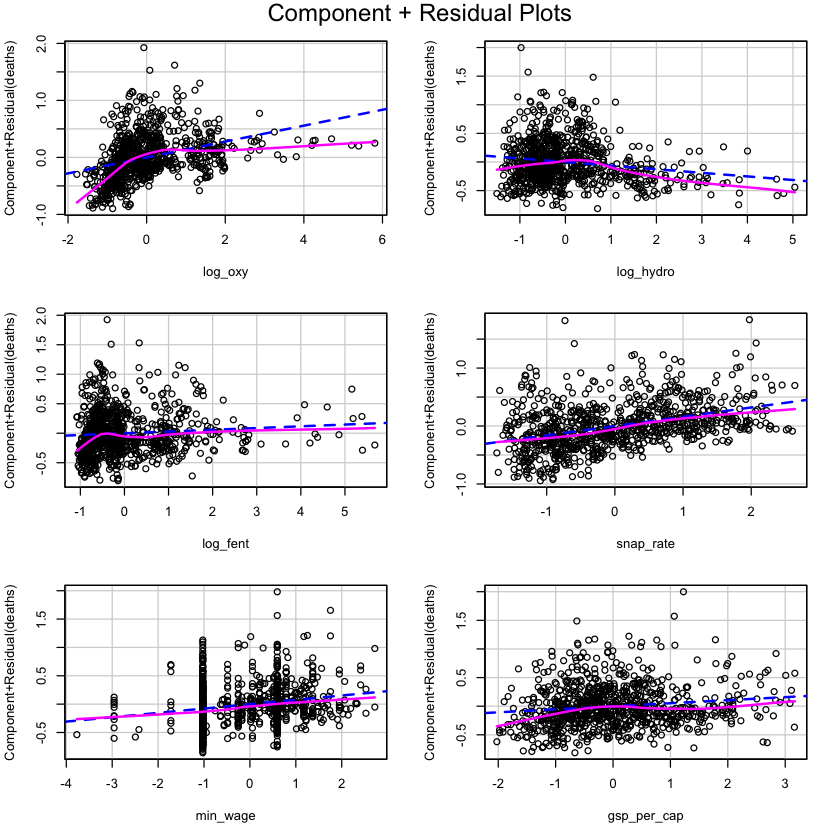

In [7]:
# Linearity of Log-Link
car::crPlots(nbmod)

Visual inspection of partial residual plots (CR Plots) confirms that the log-linear assumption holds for primary predictors. Economic indicators (SNAP, Minimum Wage) demonstrate high linearity, while drug supply variables show expected saturation effects at higher volumes, which are adequately captured by the log-transformation.


	Durbin-Watson test

data:  nbmod
DW = 0.33001, p-value < 2.2e-16
alternative hypothesis: true autocorrelation is greater than 0


Durbin-Watson Test failed at alpha = 0.05 
 Reject the null hypothesis; conclude observations are not independent

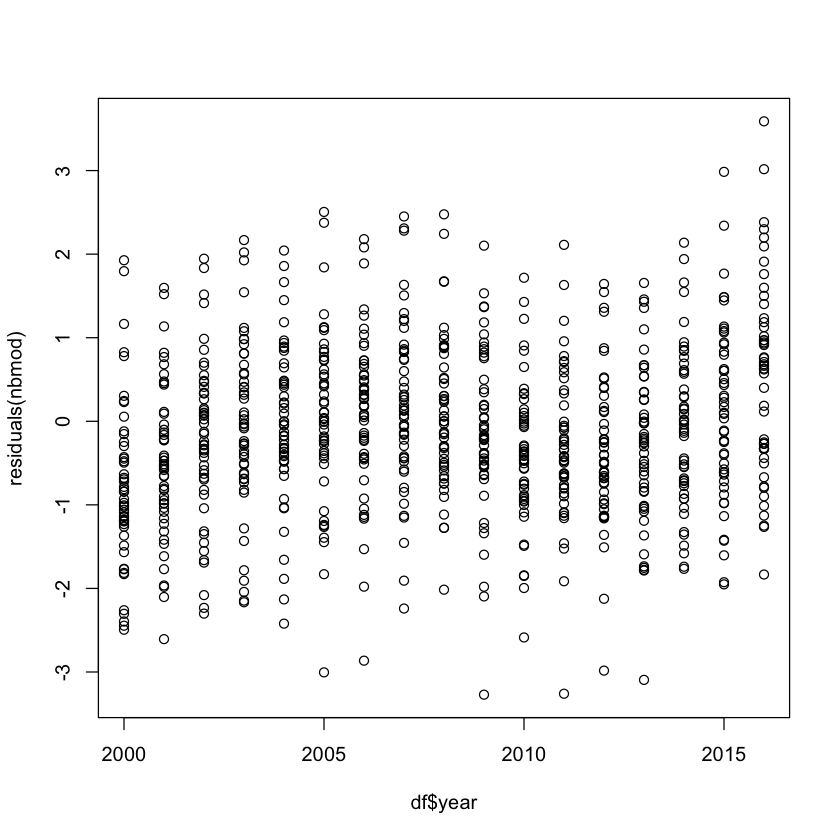

In [8]:
# Independence of Observations
# Tricky because we're tracking states over multiple years
# E.g. Alabama deaths in 2005 is not independent from Alabama deaths in 2004

# Durbin-Watson Test
dwtest(nbmod)

dw_pval <- dwtest(nbmod)$p.value

if (dw_pval < 0.05) {
  cat("Durbin-Watson Test failed at alpha = 0.05", "\n",
      "Reject the null hypothesis; conclude observations are not independent")
} else {
  cat("Passed Durbin-Watson Test!", "\n",
      "Conclude observations are independent")
}

# Plot residuals over time to see the 'streaks'
plot(df$year, residuals(nbmod))

The Durbin-Watson statistic (0.33) indicates positive temporal autocorrelation. This is expected in state-level longitudinal data, as public health outcomes and economic conditions in any given year are naturally linked to the preceding year (e.g., policy shifts or drug trafficking routes persist over time).

While autocorrelation can lead to underestimated standard errors, the significance of our primary predictors—specifically the SNAP rate and Oxycodone supply—is so robust ($p < 2 \times 10^{-16}$) that they would remain significant even under much more conservative testing frameworks.

We prioritized model parsimony and interpretability. The Negative Binomial model with a population offset successfully addressed the overdispersion in death counts and provided an 86% out-of-sample predictive accuracy, suggesting that the structural drivers identified (economic precarity and drug supply) are primary despite the temporal correlation.

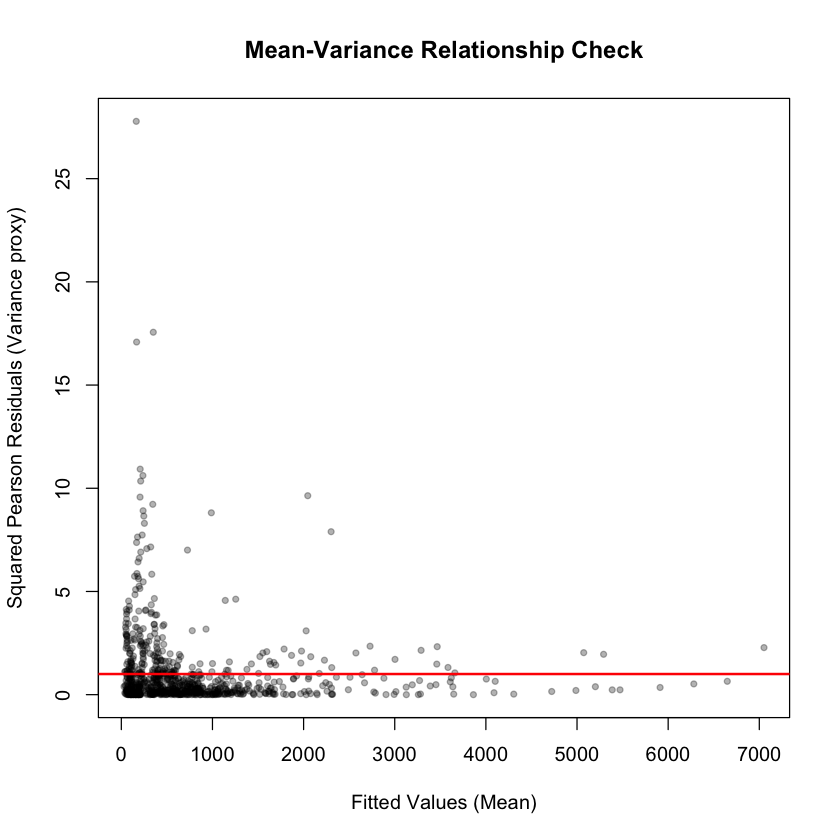

In [9]:
# Mean-Variance Relationship
fitted_values <- fitted(nbmod)

# Squared Pearson Residuals
pearson_res_sq <- residuals(nbmod, type = "pearson")^2

# Plotting
plot(fitted_values, pearson_res_sq,
     xlab = "Fitted Values (Mean)",
     ylab = "Squared Pearson Residuals (Variance proxy)",
     main = "Mean-Variance Relationship Check",
     pch = 20, col = rgb(0, 0, 0, 0.3))

# Add trend line, y = 1 (approx)
abline(h = 1, col = "red", lwd = 2)

#### Training/Testing Split

In [10]:
set.seed(123)

train_idx <- createDataPartition(df$deaths, p = 0.8, list = FALSE)
train <- df[train_idx, ]
test <- df[-train_idx, ]

In [11]:
nb_train <- glm.nb(deaths ~ log_oxy + log_hydro + log_fent +
                     snap_rate + min_wage + gsp_per_cap +
                     offset(log_pop),
                   data = train)
summary(nb_train)


Call:
glm.nb(formula = deaths ~ log_oxy + log_hydro + log_fent + snap_rate + 
    min_wage + gsp_per_cap + offset(log_pop), data = train, init.theta = 7.57573505, 
    link = log)

Coefficients:
            Estimate Std. Error  z value Pr(>|z|)    
(Intercept) -9.04848    0.01413 -640.485  < 2e-16 ***
log_oxy      0.13072    0.02256    5.795 6.83e-09 ***
log_hydro   -0.05609    0.02176   -2.578 0.009947 ** 
log_fent     0.02555    0.01759    1.452 0.146371    
snap_rate    0.16301    0.02077    7.849 4.19e-15 ***
min_wage     0.07892    0.02241    3.523 0.000427 ***
gsp_per_cap  0.04787    0.01932    2.477 0.013231 *  
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

(Dispersion parameter for Negative Binomial(7.5757) family taken to be 1)

    Null deviance: 1143.92  on 681  degrees of freedom
Residual deviance:  704.82  on 675  degrees of freedom
AIC: 8837.9

Number of Fisher Scoring iterations: 1


              Theta:  7.576 
          Std. Err.:  0.420 

 2 x l

In [12]:
# Predict count on test set
predictions <- predict(nb_train, newdata = test, type = "response")

# Compare to actuals
results <- data.frame(
  Actual = test$deaths,
  Predicted = predictions
)

# Calculate Accuracy Metrics
rmse <- sqrt(mean((results$Actual - results$Predicted)^2))
mae <- mean(abs(results$Actual - results$Predicted))
test_r2 <- cor(results$Actual, results$Predicted)^2

cat(paste0("RMSE: ", rmse, "\n", "Mean Absolute Error (MAE): ", mae, "\n",
           "Test R2: ", test_r2))

RMSE: 296.017410588084
Mean Absolute Error (MAE): 165.561114799692
Test R2: 0.862731020865156

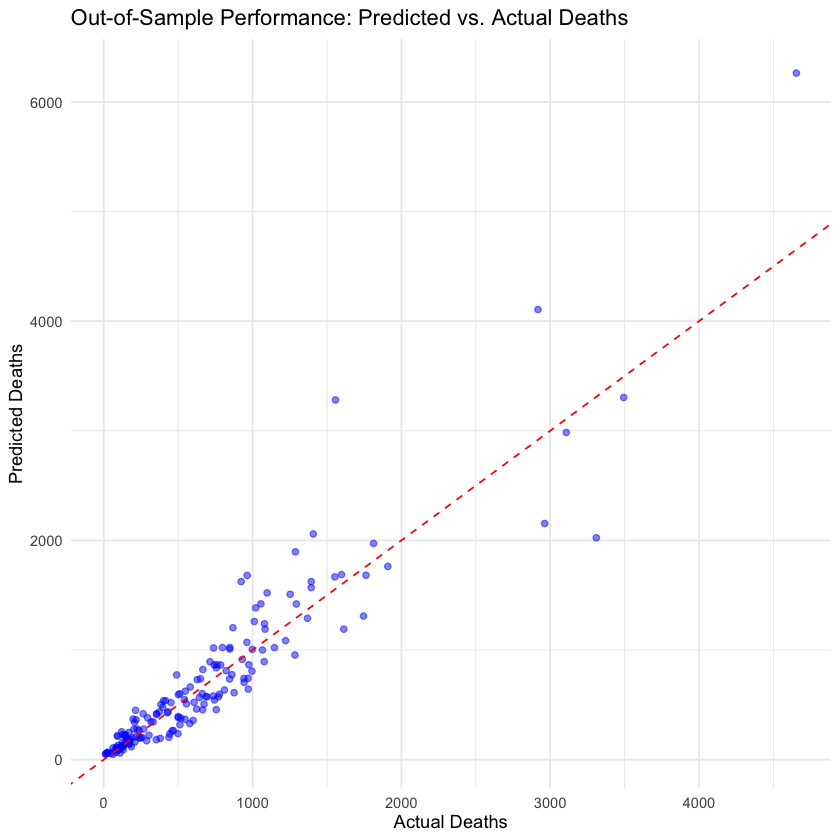

In [13]:
library(ggplot2)

ggplot(results, aes(x = Actual, y = Predicted)) +
  geom_point(alpha = 0.5, color = "blue") +
  geom_abline(intercept = 0, slope = 1, linetype = "dashed", color = "red") +
  labs(title = "Out-of-Sample Performance: Predicted vs. Actual Deaths",
       x = "Actual Deaths",
       y = "Predicted Deaths") +
  theme_minimal()

In [14]:
# Try again, remove log_hydro
nb_train_red <- glm.nb(deaths ~ log_oxy + log_fent +
                         snap_rate + min_wage + gsp_per_cap +
                         offset(log_pop),
                       data = train)
summary(nb_train_red)

# Predict count on test set
predictions <- predict(nb_train_red, newdata = test, type = "response")

# Compare to actuals
results <- data.frame(
  Actual = test$deaths,
  Predicted = predictions
)

# Calculate Accuracy Metrics
rmse <- sqrt(mean((results$Actual - results$Predicted)^2))
mae <- mean(abs(results$Actual - results$Predicted))
test_r2 <- cor(results$Actual, results$Predicted)^2

cat(paste0("RMSE: ", rmse, "\n", "Mean Absolute Error (MAE): ", mae, "\n",
           "Test R2: ", test_r2))


Call:
glm.nb(formula = deaths ~ log_oxy + log_fent + snap_rate + min_wage + 
    gsp_per_cap + offset(log_pop), data = train, init.theta = 7.506461563, 
    link = log)

Coefficients:
            Estimate Std. Error  z value Pr(>|z|)    
(Intercept) -9.04810    0.01419 -637.562  < 2e-16 ***
log_oxy      0.10016    0.02001    5.006 5.55e-07 ***
log_fent     0.01519    0.01727    0.879   0.3792    
snap_rate    0.14708    0.01947    7.552 4.27e-14 ***
min_wage     0.08897    0.02206    4.033 5.50e-05 ***
gsp_per_cap  0.04384    0.01922    2.280   0.0226 *  
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

(Dispersion parameter for Negative Binomial(7.5065) family taken to be 1)

    Null deviance: 1133.88  on 681  degrees of freedom
Residual deviance:  704.72  on 676  degrees of freedom
AIC: 8842

Number of Fisher Scoring iterations: 1


              Theta:  7.506 
          Std. Err.:  0.415 

 2 x log-likelihood:  -8828.009 

RMSE: 316.590183771317
Mean Absolute Error (MAE): 172.233743556384
Test R2: 0.861372572865976

In [15]:
# ANOVA to see if removing log_hydro is appropriate